In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d sunilthite/cat-or-dog-image-classification
!unzip -q cat-or-dog-image-classification.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/sunilthite/cat-or-dog-image-classification
License(s): other
 95% 571M/599M [00:04<00:00, 101MB/s]
100% 599M/599M [00:06<00:00, 95.5MB/s]


In [14]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [15]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Training data with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Validation data (NO augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "/content/dataset/Train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    "/content/dataset/Test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Classes:", train_generator.class_indices)

Found 23650 images belonging to 2 classes.
Found 3863 images belonging to 2 classes.
Classes: {'Cat': 0, 'Dog': 1}


In [16]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)   # Binary classification

model = Model(inputs=base_model.input, outputs=output)

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    verbose=1
)

Epoch 1/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 333s 432ms/step - accuracy: 0.9608 - loss: 0.0999 - val_accuracy: 0.9909 - val_loss: 0.0305
Epoch 2/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 309s 418ms/step - accuracy: 0.9872 - loss: 0.0356 - val_accuracy: 0.9886 - val_loss: 0.0276
Epoch 3/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 313s 424ms/step - accuracy: 0.9881 - loss: 0.0312 - val_accuracy: 0.9852 - val_loss: 0.0370
Epoch 4/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 314s 425ms/step - accuracy: 0.9906 - loss: 0.0265 - val_accuracy: 0.9909 - val_loss: 0.0250
Epoch 5/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 314s 424ms/step - accuracy: 0.9900 - loss: 0.0258 - val_accuracy: 0.9902 - val_loss: 0.0264
Epoch 6/6
740/740 ━━━━━━━━━━━━━━━━━━━━ 314s 424ms/step - accuracy: 0.9912 - loss: 0.0243 - val_accuracy: 0.9922 - val_loss: 0.0205


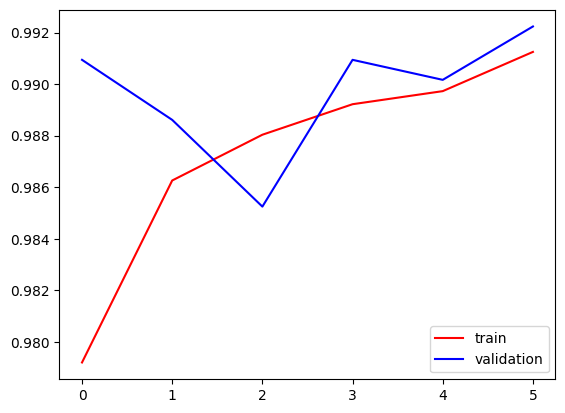

In [20]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

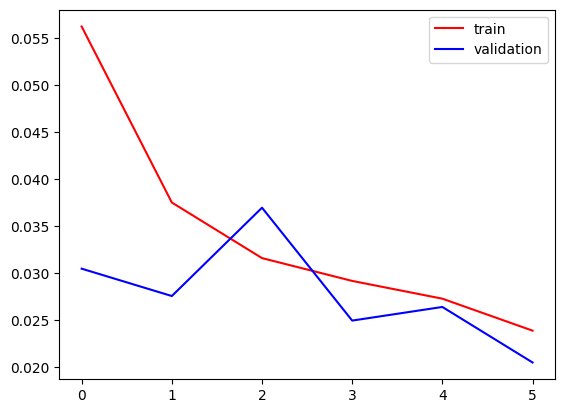

In [21]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: Cat


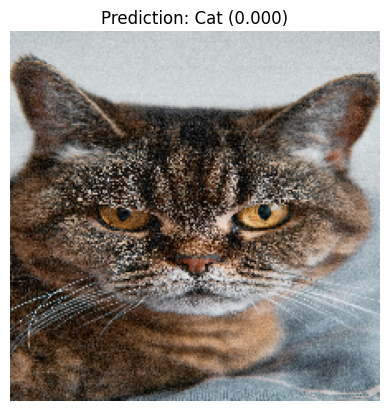

In [23]:
# ────────────────────────────────────────────────
# Optional Step 10: Simple prediction example
# ────────────────────────────────────────────────

from tensorflow.keras.preprocessing import image
import numpy as np

# Change this path to any test image you want to try
img_path = "/content/cat.avif"   # ← example

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)[0][0]

if pred < 0.5:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

plt.imshow(img)
plt.title(f"Prediction: {'Cat' if pred < 0.5 else 'Dog'} ({pred:.3f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Prediction: Dog


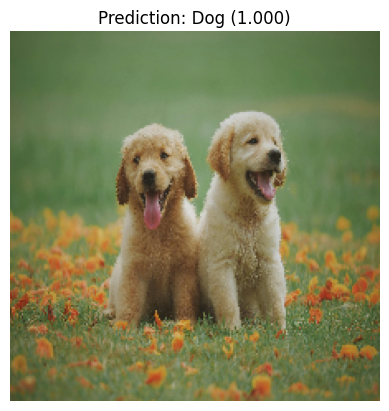

In [24]:
# ────────────────────────────────────────────────
# Optional Step 10: Simple prediction example
# ────────────────────────────────────────────────

from tensorflow.keras.preprocessing import image
import numpy as np

# Change this path to any test image you want to try
img_path = "/content/dog.jpeg"   # ← example

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)[0][0]

if pred < 0.5:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

plt.imshow(img)
plt.title(f"Prediction: {'Cat' if pred < 0.5 else 'Dog'} ({pred:.3f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: Cat


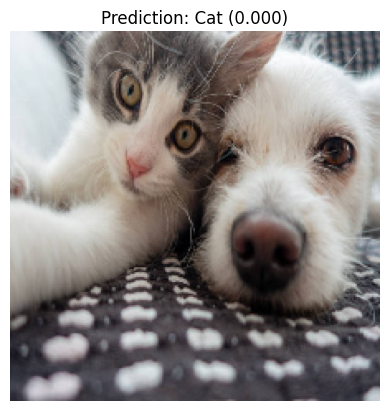

In [25]:
# ────────────────────────────────────────────────
# Optional Step 10: Simple prediction example
# ────────────────────────────────────────────────

from tensorflow.keras.preprocessing import image
import numpy as np

# Change this path to any test image you want to try
img_path = "/content/mix.jpg"   # ← example

img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

pred = model.predict(img_array)[0][0]

if pred < 0.5:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

plt.imshow(img)
plt.title(f"Prediction: {'Cat' if pred < 0.5 else 'Dog'} ({pred:.3f})")
plt.axis('off')
plt.show()